In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import shap

In [2]:
df = pd.read_csv('../Dataset/Processed/Merged_Dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.tail()

,Date,Close,High,Low,Open,Volume,Company,DE10YT_Yield,EURUSD_Close,EURUSD_Volume,...,OVX_Close,TTF_Gas_Close,VIX_Close,Gold_Close,EBITDA,Net_Income,ROA,Total_Assets,Total_Debt,Cash
615926,2025-12-19,7.58,7.61,7.54,7.57,53.8,ZIGNAGO VETRO,2.8925,1.1708,40683.0,...,33.62,28.20,14.91,3703.98,NaN,NaN,NaN,NaN,NaN,NaN
615927,2025-12-22,7.63,7.70,7.48,7.57,91.6,ZIGNAGO VETRO,2.9044,1.1760,48571.0,...,33.03,27.77,14.08,3777.43,NaN,NaN,NaN,NaN,NaN,NaN
615928,2025-12-23,7.67,7.75,7.61,7.71,50.4,ZIGNAGO VETRO,2.8647,1.1794,55315.0,...,33.02,27.78,14.00,3800.40,NaN,NaN,NaN,NaN,NaN,NaN
615929,2025-12-29,7.79,7.80,7.63,7.63,78.6,ZIGNAGO VETRO,2.8257,1.1772,50852.0,...,32.16,28.69,14.20,3679.45,NaN,NaN,NaN,NaN,NaN,NaN
615930,2025-12-30,7.77,7.84,7.72,7.82,42.7,ZIGNAGO VETRO,2.8533,1.1746,44821.0,...,30.76,27.80,14.33,3691.29,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
features = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 
    'Euribor_3M', 'FTMIB_Close', 'FTMIB_Volume', 'GVZ_Close', 
    'IT10YT_Yield', 'IT_Inflation', 'IT_GDP', 'IT_Unemployment', 
    'Brent_Close', 'Brent_Volume', 'OVX_Close', 
    'TTF_Gas_Close', 'VIX_Close', 'Gold_Close'
]

targets = ['EBITDA', 'ROA', 'Net_Income']

# Absolute Target Analysis


                                EBITDA                                
Total valid 90-day windows extracted: 4446

Top 10 Features by Mutual Information for EBITDA:
           Feature  MI_Score
       Volume_MEAN  0.572950
        Volume_STD  0.437810
EURUSD_Volume_MEAN  0.048162
  Brent_Volume_STD  0.038688
  IT_Inflation_STD  0.036853
  EURUSD_Close_STD  0.028724
 Brent_Volume_MEAN  0.026894
 FTMIB_Volume_MEAN  0.026385
 EURUSD_Volume_STD  0.023816
     GVZ_Close_STD  0.022416

Training Random Forest Regressor...


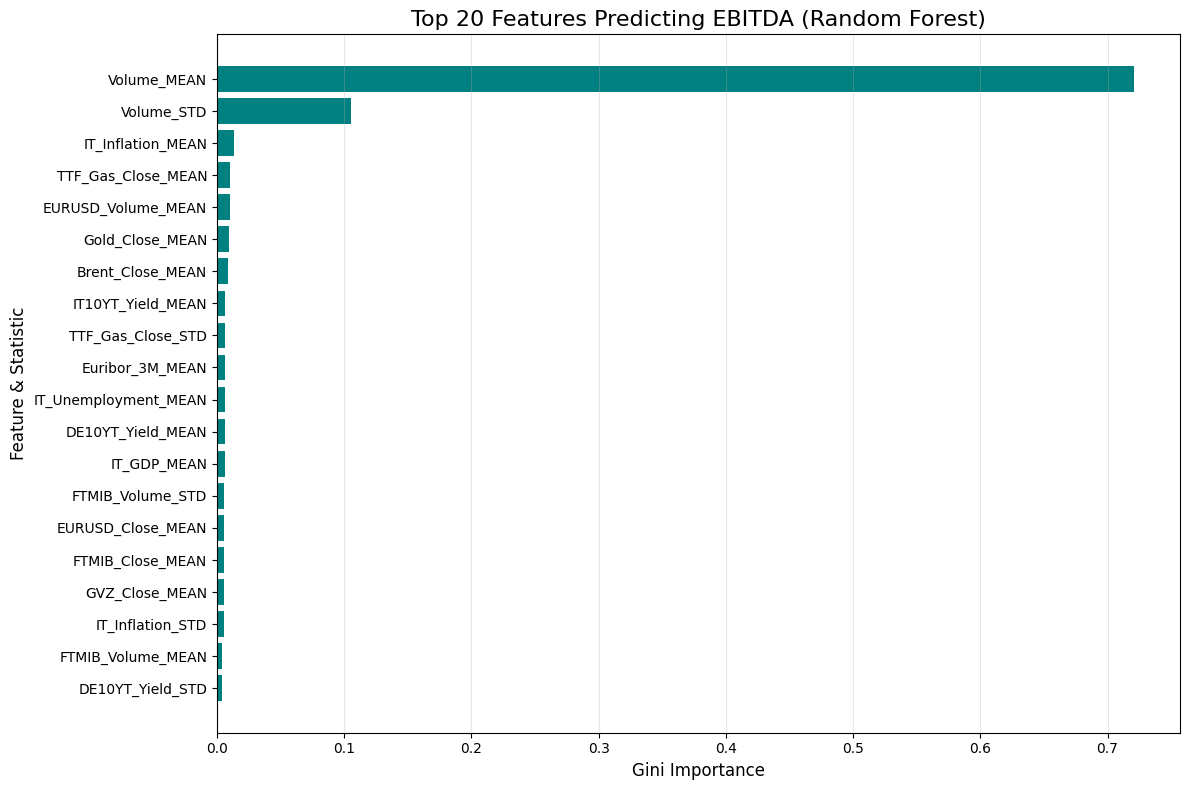


Calculating SHAP values for EBITDA...


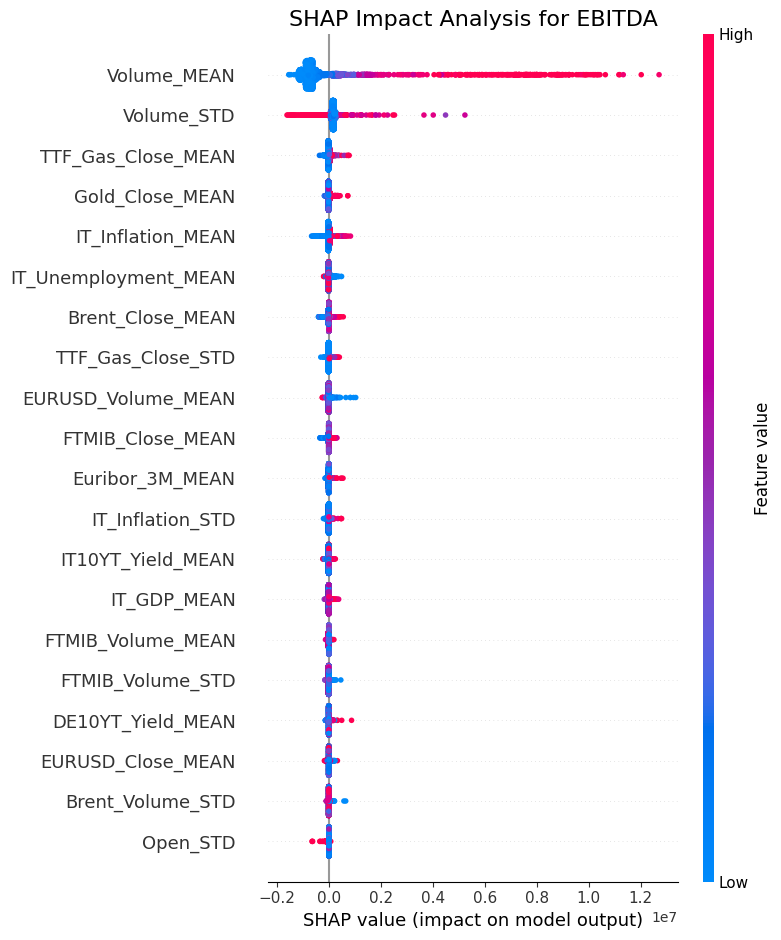


                                 ROA                                  
Total valid 90-day windows extracted: 4500

Top 10 Features by Mutual Information for ROA:
           Feature  MI_Score
       Volume_MEAN  0.201891
        Volume_STD  0.149832
EURUSD_Volume_MEAN  0.017014
  IT_Inflation_STD  0.010302
         High_MEAN  0.008986
        Close_MEAN  0.008985
          Low_MEAN  0.008975
         Open_MEAN  0.008972
   Gold_Close_MEAN  0.008628
     GVZ_Close_STD  0.008257

Training Random Forest Regressor...


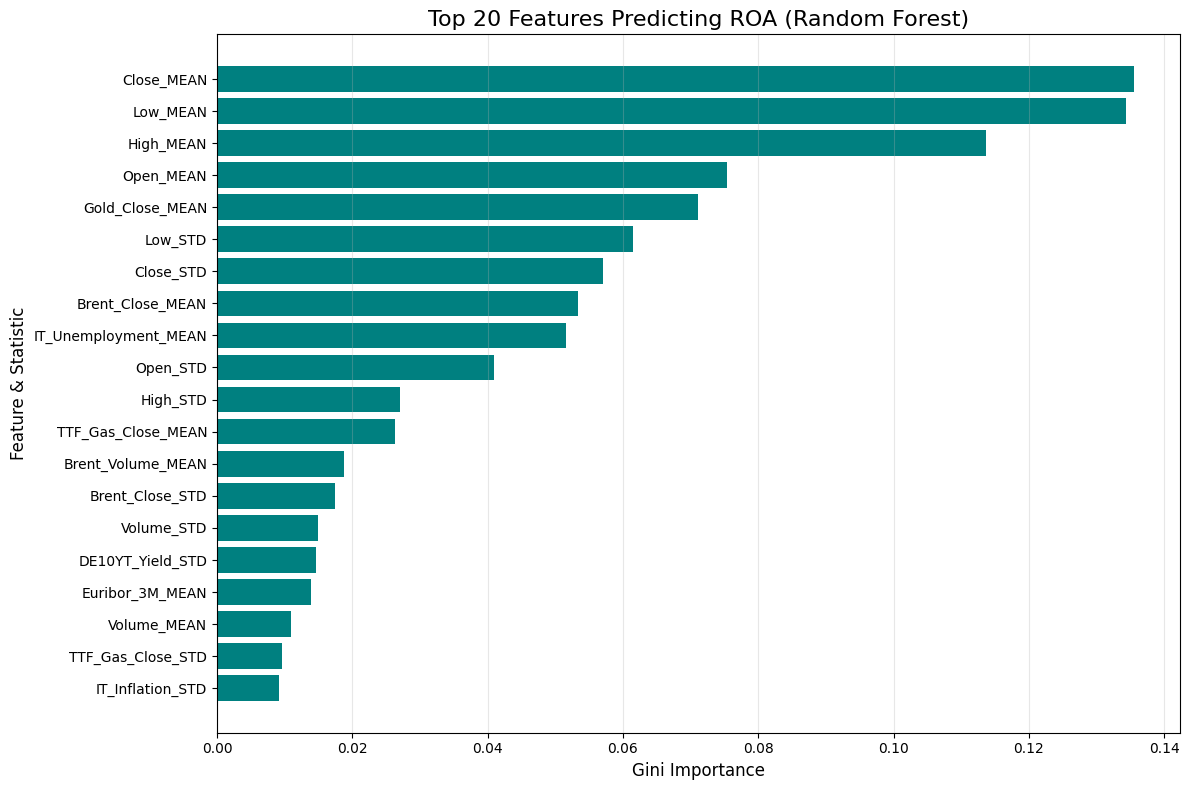


Calculating SHAP values for ROA...


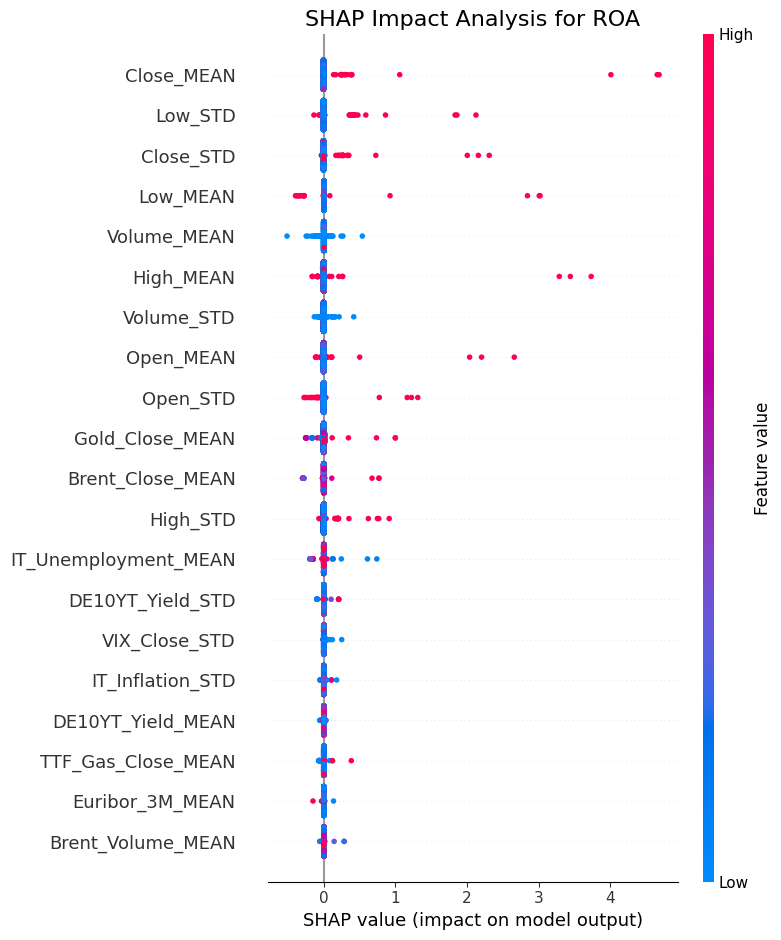


                              Net_Income                              
Total valid 90-day windows extracted: 4503

Top 10 Features by Mutual Information for Net_Income:
           Feature  MI_Score
       Volume_MEAN  0.497448
        Volume_STD  0.350914
EURUSD_Volume_MEAN  0.050664
  Brent_Volume_STD  0.050645
 Brent_Volume_MEAN  0.050352
  IT_Inflation_STD  0.046384
  EURUSD_Close_STD  0.046021
  FTMIB_Volume_STD  0.044853
 EURUSD_Volume_STD  0.041503
  IT10YT_Yield_STD  0.040889

Training Random Forest Regressor...


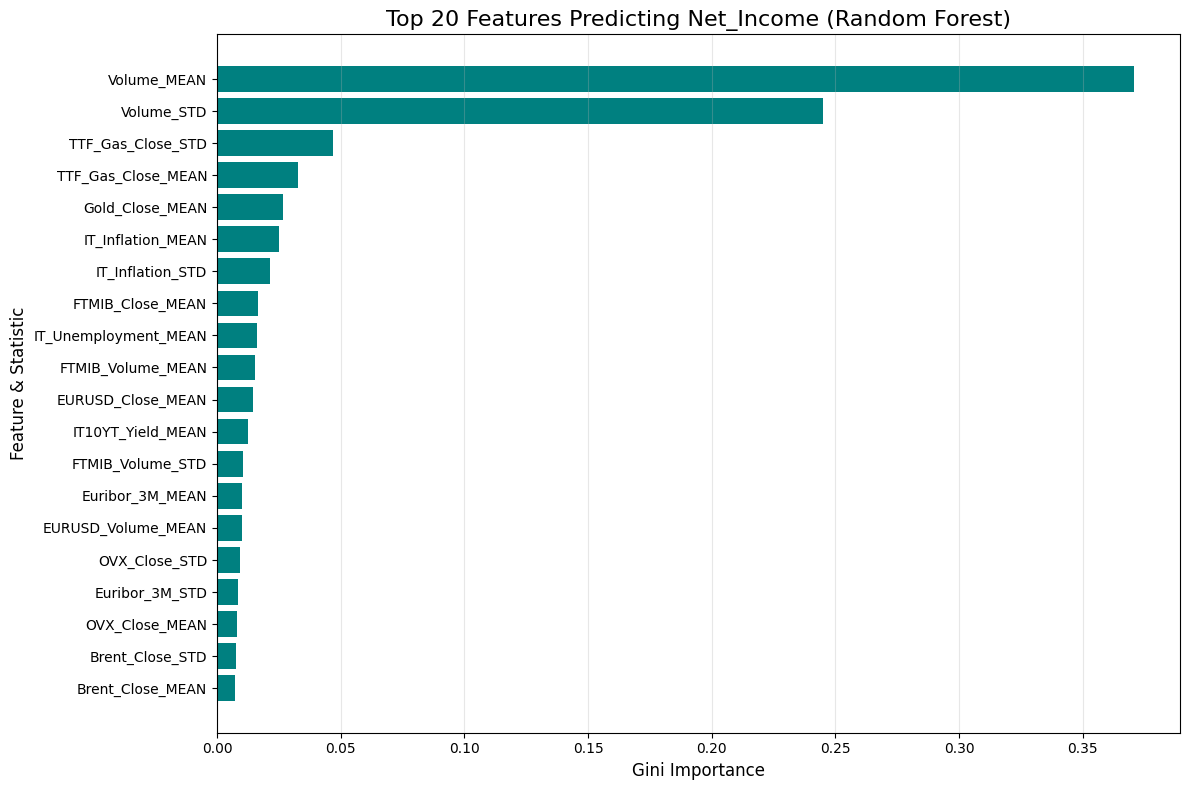


Calculating SHAP values for Net_Income...


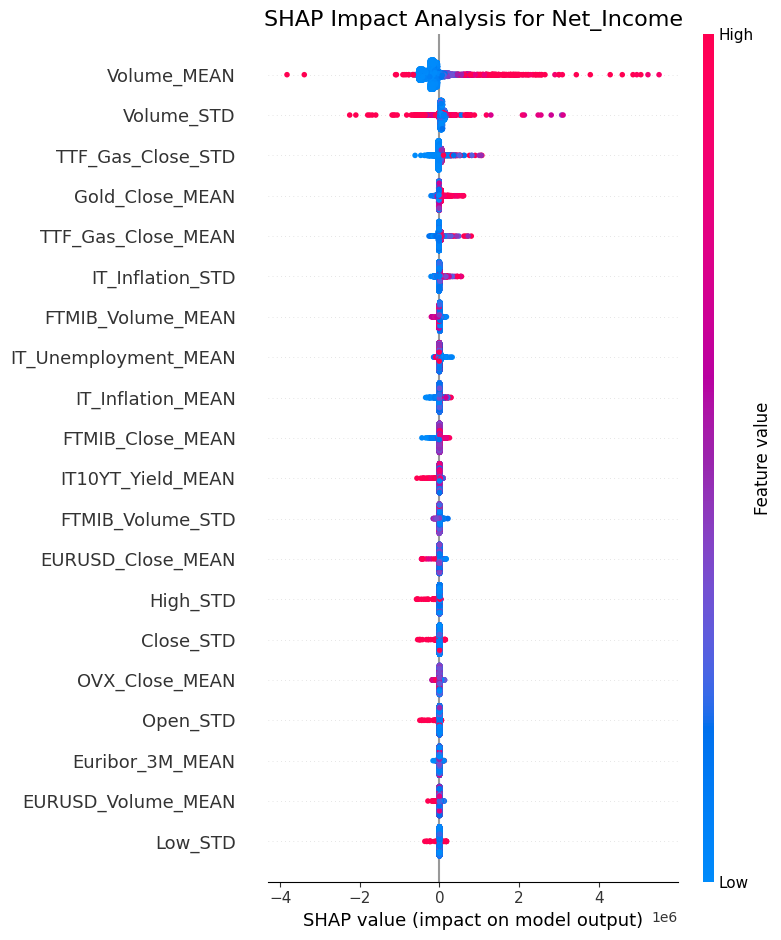

In [4]:
for target in targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []

    target_indices = df[df[target].notna()].index

    for idx in target_indices:
        target_date = df.loc[idx, 'Date']
        company = df.loc[idx, 'Company']
        target_value = df.loc[idx, target]
        
        start_date = target_date - pd.Timedelta(days=90)
        
        window = df[(df['Company'] == company) & 
                    (df['Date'] > start_date) & 
                    (df['Date'] <= target_date)]
        
        if len(window) > 40:
            window_stats = {}
            for feat in features:
                window_stats[f"{feat}_MEAN"] = window[feat].mean()
                window_stats[f"{feat}_STD"] = window[feat].std()
                
            X_aggregated.append(window_stats)
            y_values.append(target_value)

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    print(f"Total valid 90-day windows extracted: {len(X_df)}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # Mutual Information Regression
    mi_scores = mutual_info_regression(X_scaled, y_series, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X_df.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    print(f"\nTop 10 Features by Mutual Information for {target}:")
    print(mi_df.head(10).to_string(index=False))

    # 3. RANDOM FOREST TRAINING
    print("\nTraining Random Forest Regressor...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
    rf.fit(X_scaled, y_series)

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Plotting random forest
    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='teal')
    plt.title(f'Top 20 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature & Statistic', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    rf_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Plotting SHAP values
    print(f"\nCalculating SHAP values for {target}...")
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    
    # show=False prevents SHAP from immediately consuming the plot, allowing us to save it
    shap.summary_plot(shap_values, X_df, plot_type="dot", show=False)
    plt.tight_layout()
    
    shap_save_path = f'../Analysis/Features Importance/Absolute Target/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Momentum and Direction

In [5]:
directional_targets = []

for target in targets:
    df_valid = df.dropna(subset=[target]).copy()
    
    # Calculate Quarter-over-Quarter percentage change
    qoq_col = f"{target}_QoQ_Pct"
    df_valid[qoq_col] = df_valid.groupby('Company')[target].pct_change(1)
    
    # Define Direction: 1 if UP (QoQ > 0), 0 if DOWN or FLAT
    dir_col = f"{target}_Direction_Up"
    df_valid[dir_col] = np.where(df_valid[qoq_col] > 0, 1, 0)
    
    # If QoQ is NaN (first known value of the company), set Direction to NaN
    df_valid.loc[df_valid[qoq_col].isna(), dir_col] = np.nan
    df.loc[df_valid.index, dir_col] = df_valid[dir_col]
    directional_targets.append(dir_col)


                         EBITDA_Direction_Up                          
Total valid 90-day windows extracted for classification: 4397

Top 10 Features by Mutual Information for EBITDA_Direction_Up:
             Feature  MI_Score
     Euribor_3M_MEAN  0.243558
      Euribor_3M_STD  0.241923
   FTMIB_Volume_MEAN  0.241496
       OVX_Close_STD  0.239448
      OVX_Close_MEAN  0.238996
      GVZ_Close_MEAN  0.237318
   IT10YT_Yield_MEAN  0.236895
   DE10YT_Yield_MEAN  0.236643
IT_Unemployment_MEAN  0.235946
      VIX_Close_MEAN  0.235520


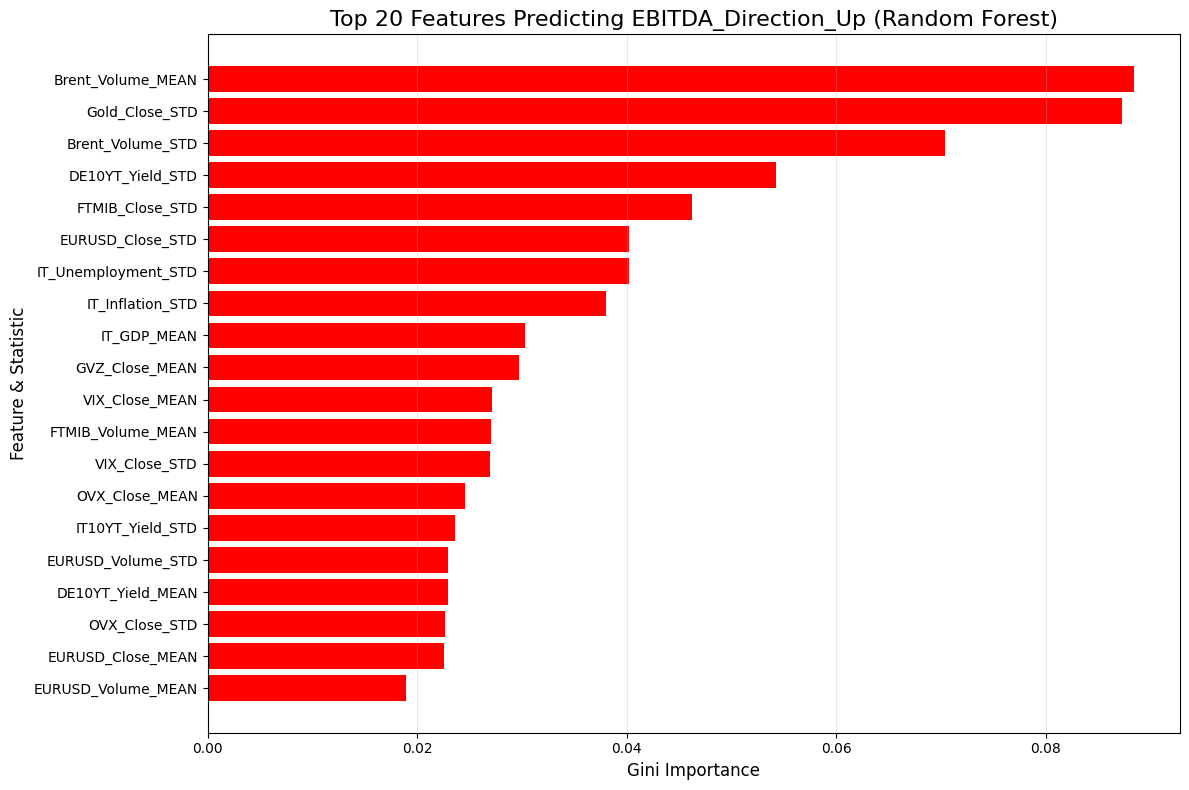


Calculating SHAP values for EBITDA_Direction_Up...


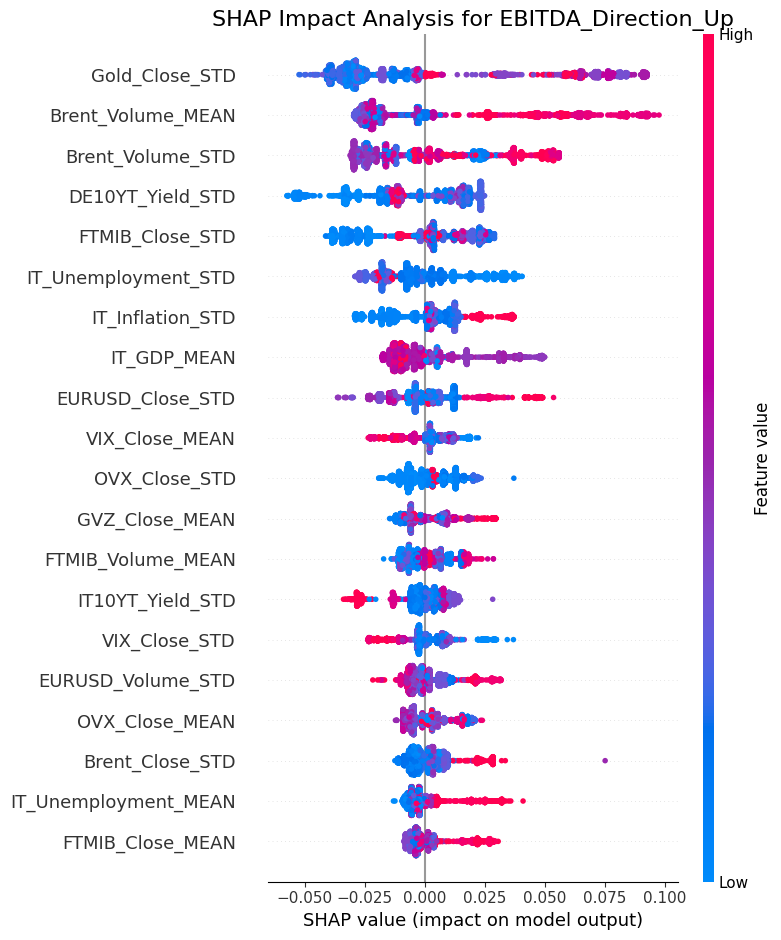


                           ROA_Direction_Up                           
Total valid 90-day windows extracted for classification: 4456

Top 10 Features by Mutual Information for ROA_Direction_Up:
             Feature  MI_Score
    FTMIB_Close_MEAN  0.168742
       VIX_Close_STD  0.165030
  TTF_Gas_Close_MEAN  0.163195
      OVX_Close_MEAN  0.162146
      GVZ_Close_MEAN  0.161653
IT_Unemployment_MEAN  0.160430
     Euribor_3M_MEAN  0.158602
   IT_Inflation_MEAN  0.157703
   Brent_Volume_MEAN  0.157488
     Gold_Close_MEAN  0.157473


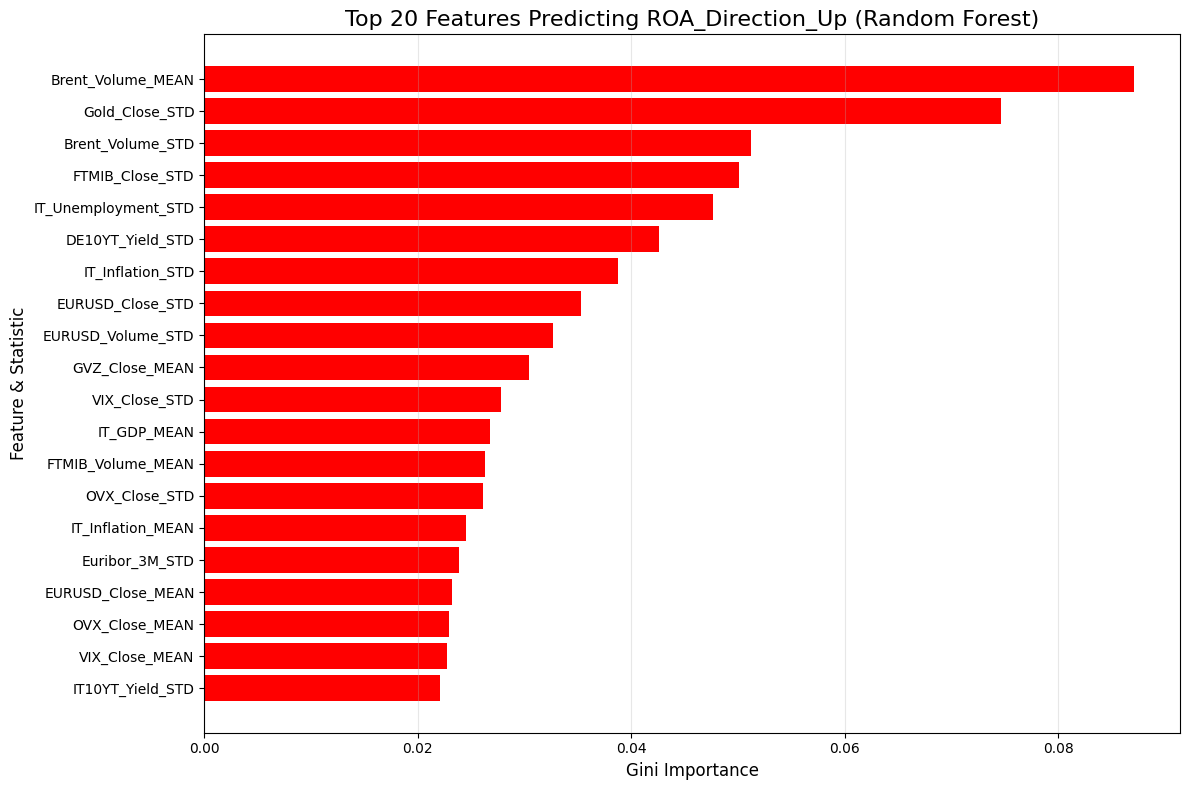


Calculating SHAP values for ROA_Direction_Up...


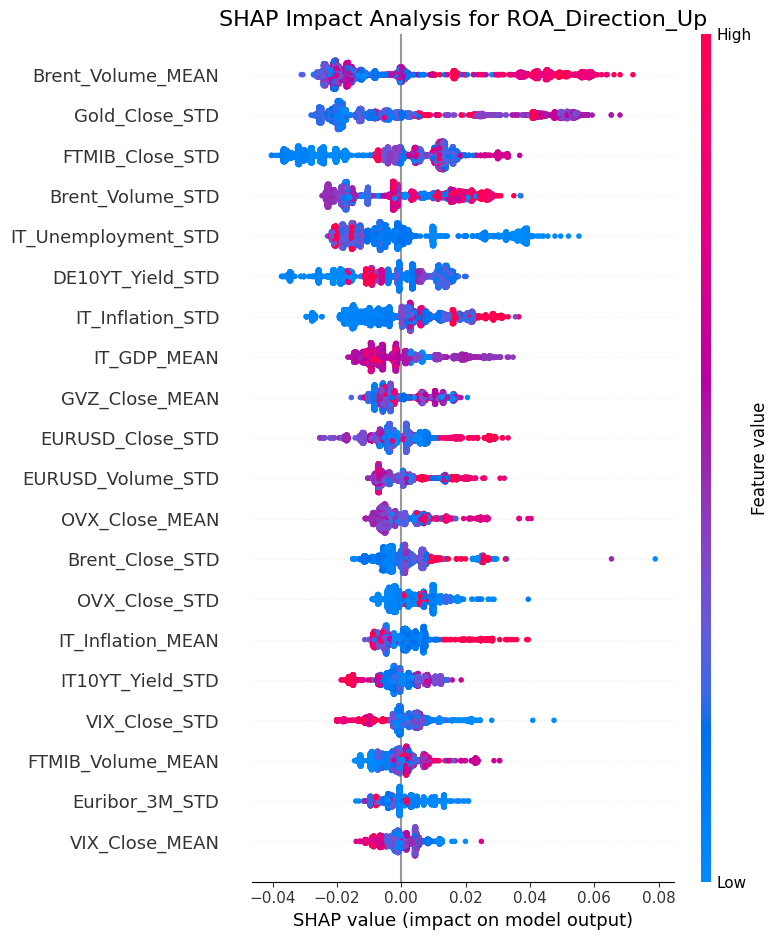


                       Net_Income_Direction_Up                        
Total valid 90-day windows extracted for classification: 4459

Top 10 Features by Mutual Information for Net_Income_Direction_Up:
           Feature  MI_Score
 EURUSD_Close_MEAN  0.189505
   Gold_Close_MEAN  0.188727
    OVX_Close_MEAN  0.187513
  IT10YT_Yield_STD  0.187414
    Euribor_3M_STD  0.187260
     VIX_Close_STD  0.186584
    VIX_Close_MEAN  0.186504
TTF_Gas_Close_MEAN  0.186089
 Brent_Volume_MEAN  0.184706
  FTMIB_Volume_STD  0.183627


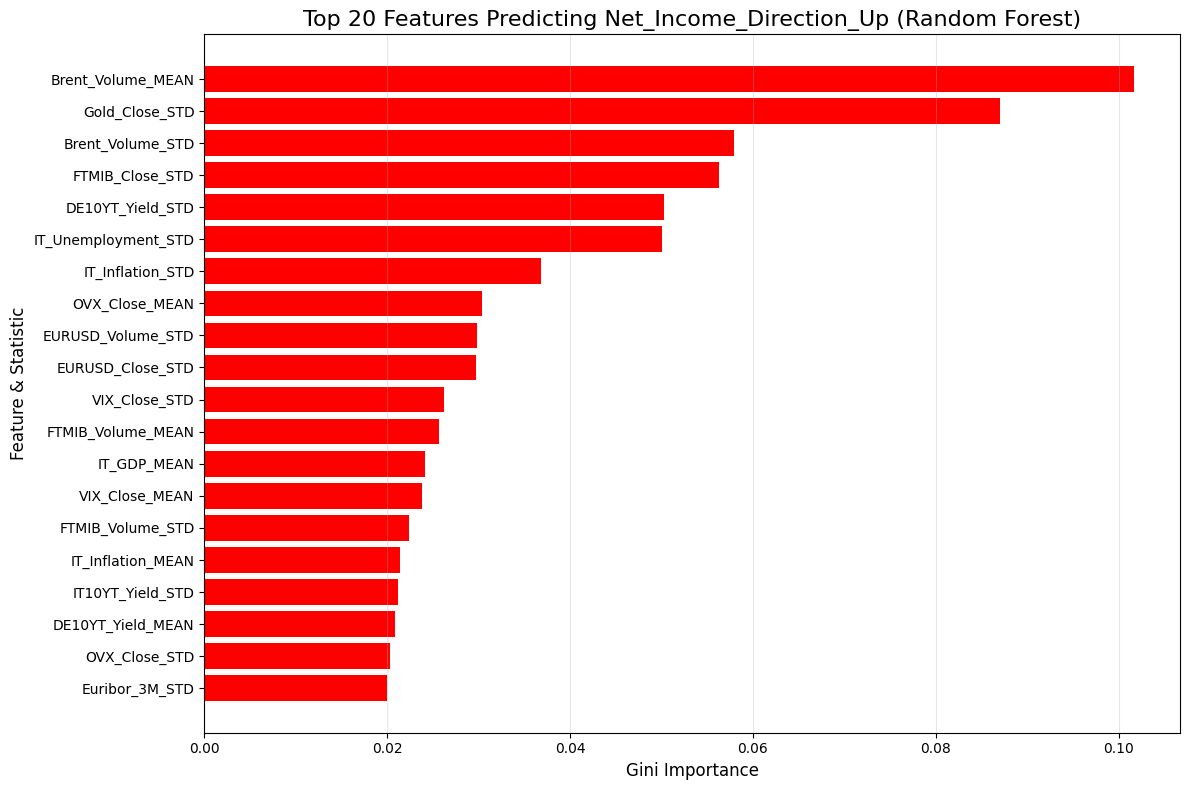


Calculating SHAP values for Net_Income_Direction_Up...


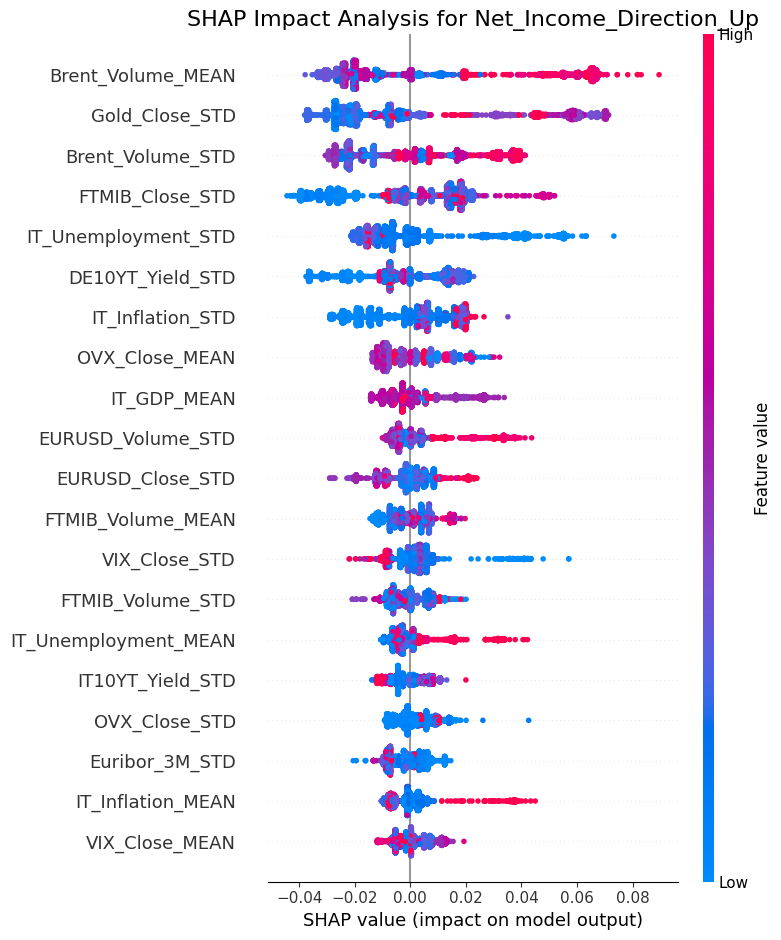

In [7]:
for target in directional_targets:
    print(f"\n{'='*70}")
    print(f"{target:^70}")
    print(f"{'='*70}")

    X_aggregated = []
    y_values = []
    target_indices = df[df[target].notna()].index

    for idx in target_indices:
        target_date = df.loc[idx, 'Date']
        company = df.loc[idx, 'Company']
        target_value = df.loc[idx, target]
        
        start_date = target_date - pd.Timedelta(days=90)
        
        window = df[(df['Company'] == company) & 
                    (df['Date'] > start_date) & 
                    (df['Date'] <= target_date)]
        
        if len(window) > 40:
            window_stats = {}
            for feat in features:
                window_stats[f"{feat}_MEAN"] = window[feat].mean()
                window_stats[f"{feat}_STD"] = window[feat].std()
                
            X_aggregated.append(window_stats)
            y_values.append(target_value)

    X_df = pd.DataFrame(X_aggregated).fillna(0)
    y_series = pd.Series(y_values)
    
    print(f"Total valid 90-day windows extracted for classification: {len(X_df)}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df)
    
    # Mutual Information
    mi_scores = mutual_info_classif(X_scaled, y_series, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': X_df.columns,
        'MI_Score': mi_scores
    }).sort_values(by='MI_Score', ascending=False)
    
    print(f"\nTop 10 Features by Mutual Information for {target}:")
    print(mi_df.head(10).to_string(index=False))

    # Random Forest Classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
    rf.fit(X_scaled, y_series)

    importance_df = pd.DataFrame({
        'Feature': X_df.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Plot Classification Random Forest
    top_features = importance_df.head(20).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Importance'], color='red')
    plt.title(f'Top 20 Features Predicting {target} (Random Forest)', fontsize=16)
    plt.xlabel('Gini Importance', fontsize=12)
    plt.ylabel('Feature & Statistic', fontsize=12)
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    
    rf_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_RF.png'
    plt.savefig(rf_save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Plot SHAP Values for Class 1 (UP)
    print(f"\nCalculating SHAP values for {target}...")
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    # Random Forest Classifier returns SHAP values for both classes (0 and 1)
    # Isolate class 1 (UP Direction) to see what pushes the probability of a positive trend
    if isinstance(shap_values, list):
        shap_values_up = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_up = shap_values[:, :, 1]
    else:
        shap_values_up = shap_values
        
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Impact Analysis for {target}", fontsize=16)
    shap.summary_plot(shap_values_up, X_df, plot_type="dot", show=False)
    plt.tight_layout()
    
    shap_save_path = f'../Analysis/Features Importance/Momentum and Direction/{target}_SHAP.png'
    plt.savefig(shap_save_path, dpi=300, bbox_inches='tight')
    plt.show()
